Setup and Library Loading

In [ ]:
#Installing the necessary packages
install.packages('sqldf')
install.packages('ggplot2')
install.packages('dplyr')
library(sqldf)
library(ggplot2)
library(dplyr)

#Loading the datasets
orders <- read.csv('orders.csv')
deliveries <- read.csv('deliveries.csv')
complaints <- read.csv('complaints.csv')
app_events <- read.csv('app_events.csv')

#Cleaning the column names
colnames(orders) <- trimws(colnames(orders))
colnames(deliveries) <- trimws(colnames(deliveries))

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



SQL in R: The Financial Leak Investigation

In [ ]:
#Joining orders and deliveries to calculate 'Cost-to-Revenue' Ratio
finance_query <- "SELECT o.service_type,
       AVG(o.order_value) as avg_revenue,
       AVG(d.fuel_or_charge_cost) as avg_cost,
       (AVG(d.fuel_or_charge_cost) / AVG(o.order_value)) * 100 as cost_percent_of_rev
FROM orders o
JOIN deliveries d ON o.order_id = d.order_id
GROUP BY o.service_type
ORDER BY cost_percent_of_rev DESC"

finance_results <- sqldf(finance_query)
print("--- Finance Analysis ---")
print(finance_results)



[1] "--- Finance Analysis ---"
  service_type avg_revenue avg_cost cost_percent_of_rev
1       Retail    86.80741 12.97442            14.94621
2      Medical    86.52667 12.77296            14.76188
3       Parcel    90.15409 13.08265            14.51144
4     Business    97.45421 13.14214            13.48545
5    Passenger    97.18840 12.39908            12.75778


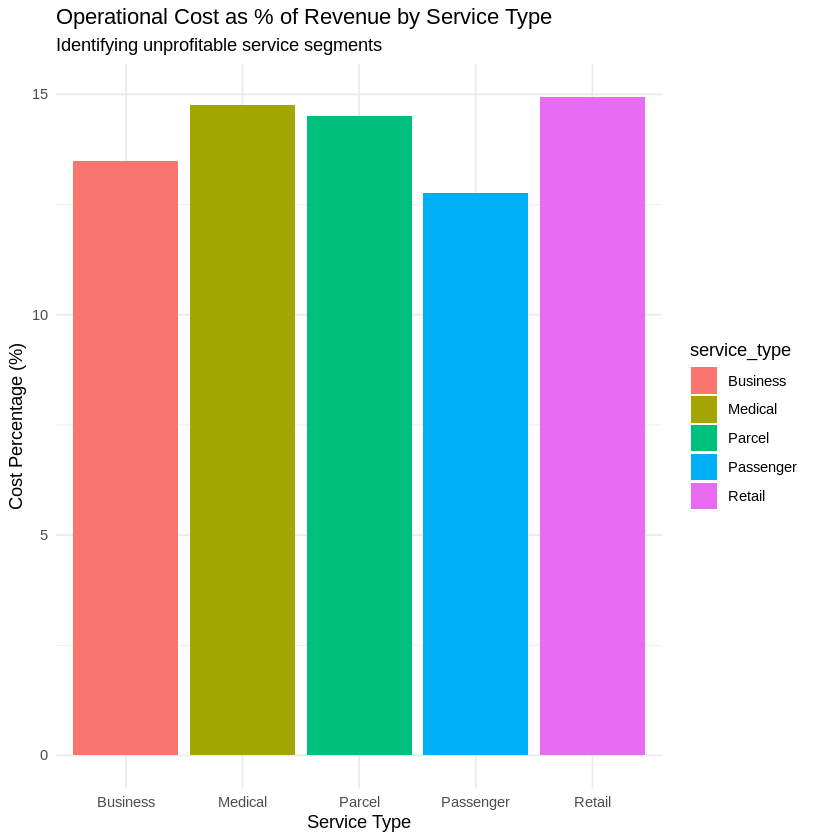

In [ ]:
#Visualization : Revenue vs Cost
ggplot(finance_results, aes(x=service_type, y=cost_percent_of_rev, fill=service_type)) +
  geom_bar(stat="identity") +
  labs(title="Operational Cost as % of Revenue by Service Type",
       subtitle="Identifying unprofitable service segments",
       y="Cost Percentage (%)", x="Service Type") +
  theme_minimal()


In [ ]:
#Standardizing the zone names to Uppercase
orders$dropoff_zone <- toupper(trimws(orders$dropoff_zone))

operations <- "SELECT
    o.dropoff_zone,
    COUNT(o.order_id) AS total_orders,
    AVG(o.order_value) AS avg_order_value,
    AVG(d.fuel_or_charge_cost) AS avg_delivery_cost,
    SUM(d.manual_route_override_count) AS total_overrides
FROM orders o
JOIN deliveries d ON o.order_id = d.order_id
WHERE o.order_value > 50
GROUP BY o.dropoff_zone
ORDER BY avg_delivery_cost DESC"

operations_results <- sqldf(operations)
print("--- Operations ---")
print(operations_results)


[1] "--- Operations ---"
  dropoff_zone total_orders avg_order_value avg_delivery_cost total_overrides
1        NORTH          111        103.3632          13.48342             113
2    RIVERSIDE          100        124.1738          13.17410              98
3         WEST          103        115.2439          13.16272             104
4      CENTRAL           74        127.2045          12.75041              75
5         EAST           91        111.5849          12.50835              92
6      AIRPORT           92        111.8274          12.34250              89
7        SOUTH           91        104.5621          12.16835              81
8          CTR           41        115.8537          11.99780              37


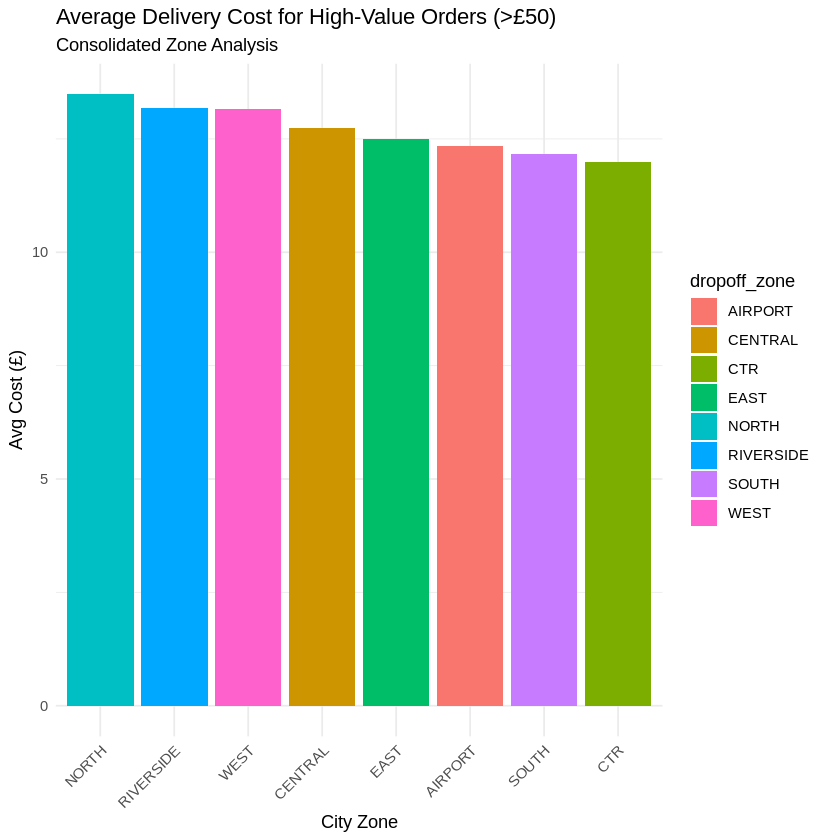

In [ ]:
#Visualisation: With cleaned, unified categories
ggplot(operations_results, aes(x=reorder(dropoff_zone, -avg_delivery_cost), y=avg_delivery_cost, fill=dropoff_zone)) +
  geom_bar(stat="identity") +
  labs(title="Average Delivery Cost for High-Value Orders (>£50)",
       subtitle="Consolidated Zone Analysis",
       x="City Zone", y="Avg Cost (£)") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

Statistical Analysis: Zonal Failure Rates

In [ ]:
#Clean the 'Messy' Zone Data (Fixes NORTH vs North)
#forcing everything to Uppercase and removing accidental spaces
orders$dropoff_zone <- toupper(trimws(orders$dropoff_zone))

#Joining Deliveries and Orders (because delivery_status and zones are in different files)
delivery_with_zones <- deliveries %>%
  inner_join(orders, by = "order_id")



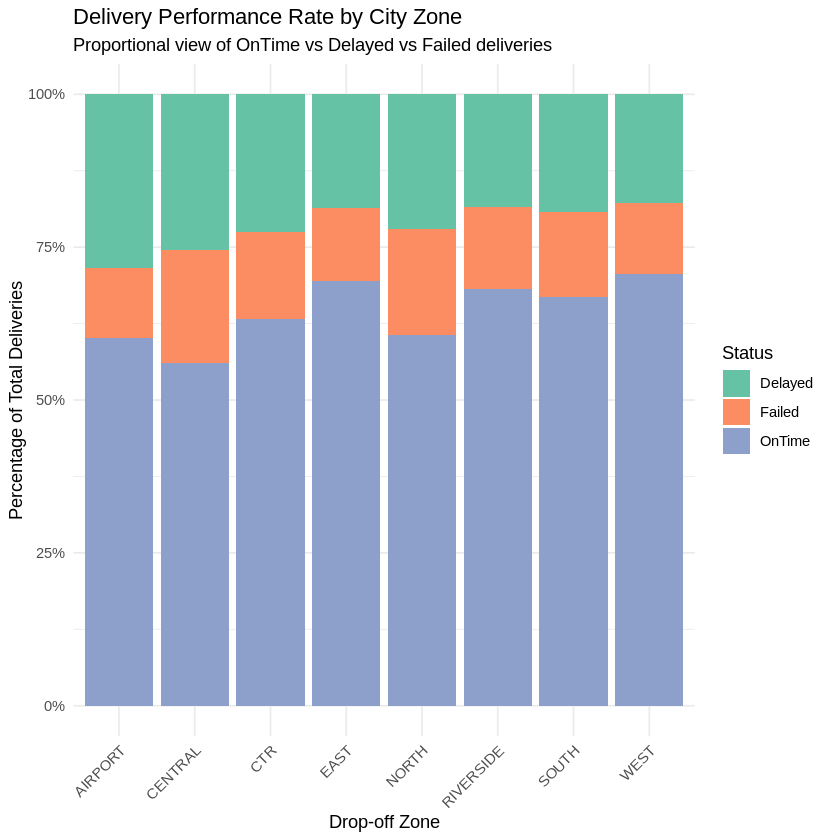

In [ ]:
#Creating a Proportion Graph (Easier to see the failure rate)
ggplot(delivery_with_zones, aes(x = dropoff_zone, fill = delivery_status)) +
  geom_bar(position = "fill") + # This stacks them to 100% so rates can be compared
  scale_y_continuous(labels = scales::percent) +
  labs(title = "Delivery Performance Rate by City Zone",
       subtitle = "Proportional view of OnTime vs Delayed vs Failed deliveries",
       y = "Percentage of Total Deliveries",
       x = "Drop-off Zone",
       fill = "Status") +
  scale_fill_brewer(palette = "Set2") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

Root Cause Analysis: Manual Overrides vs. Efficiency

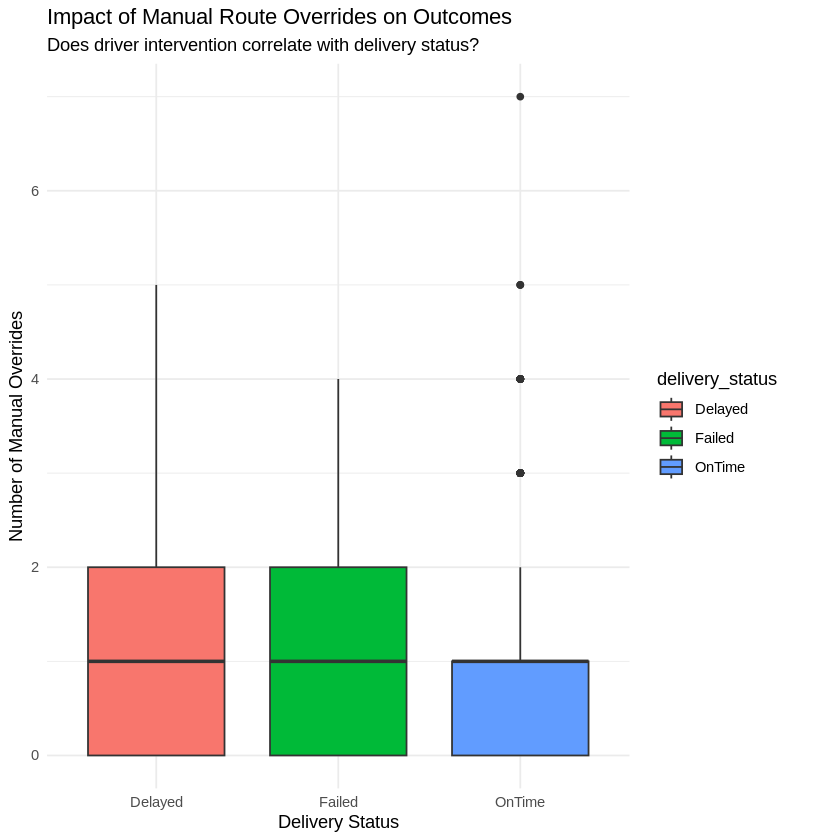

In [ ]:
# Boxplot to see if 'Delayed' deliveries have higher manual overrides
ggplot(deliveries, aes(x=delivery_status, y=manual_route_override_count, fill=delivery_status)) +
  geom_boxplot() +
  labs(title="Impact of Manual Route Overrides on Outcomes",
       subtitle="Does driver intervention correlate with delivery status?",
       x="Delivery Status", y="Number of Manual Overrides") +
  theme_minimal()

Customer Sentiment Correlation

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 14 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 14 rows containing missing values or values outside the scale range
(`geom_point()`).”


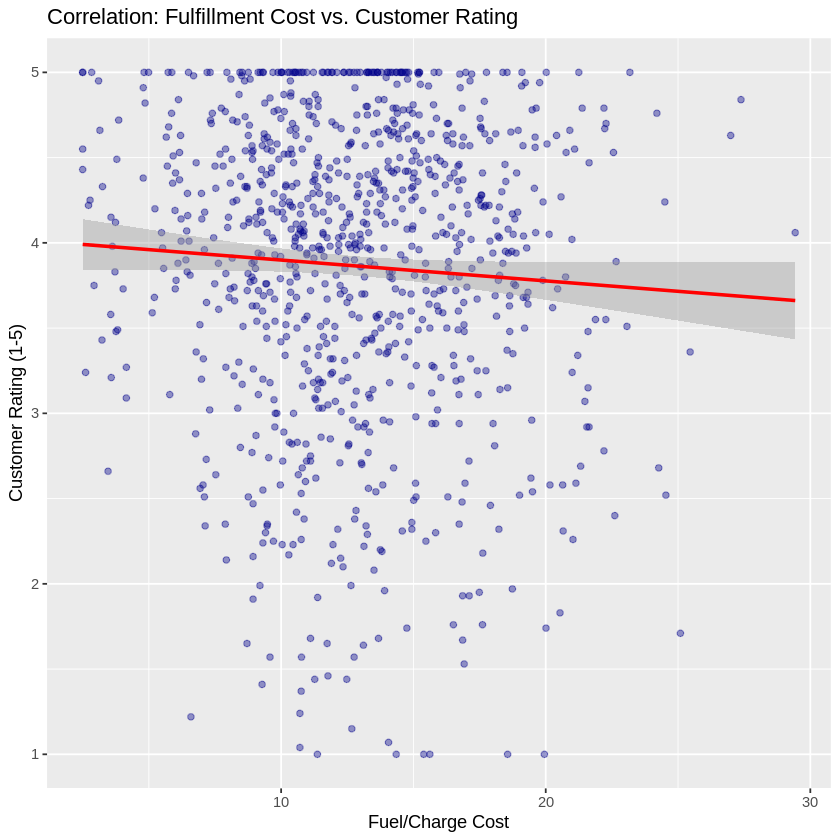

In [ ]:
#Correlation between cost and rating
ggplot(deliveries, aes(x=fuel_or_charge_cost, y=customer_rating_post_delivery)) +
  geom_point(alpha=0.4, color="darkblue") +
  geom_smooth(method="lm", color="red") +
  labs(title="Correlation: Fulfillment Cost vs. Customer Rating",
       x="Fuel/Charge Cost", y="Customer Rating (1-5)")